In [12]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [13]:
#Load dataset
df = pd.read_csv('customer_retail.csv', encoding='latin1')

print("Original shape:", df.shape)
print("First few rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

Original shape: (541909, 8)
First few rows:
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
Custom

In [14]:
#Data Cleaning

#Remove rows with missing CustomerID (required for customer-level analysis)
df = df.dropna(subset=['CustomerID'])
# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

#Remove rows with negative or zero quantity (returns/cancellations) and zero unit price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

#Calculate total spend per row
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

#Feature Engineering at Customer Level
customer_features = df.groupby('CustomerID').agg(
    total_spend=('TotalSpend', 'sum'),
    total_quantity=('Quantity', 'sum'),
    avg_unit_price=('UnitPrice', 'mean'),
    num_transactions=('InvoiceNo', 'nunique'),
    num_unique_products=('StockCode', 'nunique'),
    most_common_country=('Country', lambda x: x.mode()[0])
).reset_index()

#Create target variable: high-value customer (1 if total_spend > median, else 0)
median_spend = customer_features['total_spend'].median()
customer_features['high_value'] = (customer_features['total_spend'] > median_spend).astype(int)

print(f"\nMedian spend: {median_spend:.2f}")
print("Target distribution:\n", customer_features['high_value'].value_counts())


Median spend: 674.49
Target distribution:
 high_value
1    2169
0    2169
Name: count, dtype: int64


In [15]:
#Handle missing values & encode categorical column

#Check for any remaining missing values
print("\nMissing values in customer_features:\n", customer_features.isnull().sum())

#Encode 'most_common_country' using LabelEncoder
le_country = LabelEncoder()
customer_features['country_code'] = le_country.fit_transform(customer_features['most_common_country'])

#Select features for modeling (drop identifier and original country column)
X = customer_features.drop(['CustomerID', 'most_common_country', 'high_value'], axis=1)
y = customer_features['high_value']

#Features: total_spend, total_quantity, avg_unit_price, num_transactions, num_unique_products, country_code
print("\nFeature columns:", X.columns.tolist())


Missing values in customer_features:
 CustomerID             0
total_spend            0
total_quantity         0
avg_unit_price         0
num_transactions       0
num_unique_products    0
most_common_country    0
high_value             0
dtype: int64

Feature columns: ['total_spend', 'total_quantity', 'avg_unit_price', 'num_transactions', 'num_unique_products', 'country_code']


In [16]:
#Split data into training and testing sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
#Scale features for LR and KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Decision Tree uses original unscaled features
X_train_dt = X_train
X_test_dt = X_test

In [18]:
#Train & tune Logistic Regression
print("\nLogistic Regression")
lr_params = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']}
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Best parameters: {lr_grid.best_params_}")
print(f"Test Accuracy: {acc_lr:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))



Logistic Regression
Best parameters: {'C': 100, 'solver': 'lbfgs'}
Test Accuracy: 0.9804
Confusion Matrix:
 [[425   9]
 [  8 426]]


In [19]:
#Train & tune Decision Tree
print("\n=== Decision Tree ===")
dt_params = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_dt, y_train)
best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test_dt)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Best parameters: {dt_grid.best_params_}")
print(f"Test Accuracy: {acc_dt:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


=== Decision Tree ===
Best parameters: {'max_depth': 3, 'min_samples_split': 2}
Test Accuracy: 1.0000
Confusion Matrix:
 [[434   0]
 [  0 434]]


In [21]:
#Train & tune KNN
print("\nK-Nearest Neighbors")
knn_params = {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']}
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Best parameters: {knn_grid.best_params_}")
print(f"Test Accuracy: {acc_knn:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


K-Nearest Neighbors
Best parameters: {'n_neighbors': 3, 'weights': 'distance'}
Test Accuracy: 0.9263
Confusion Matrix:
 [[401  33]
 [ 31 403]]


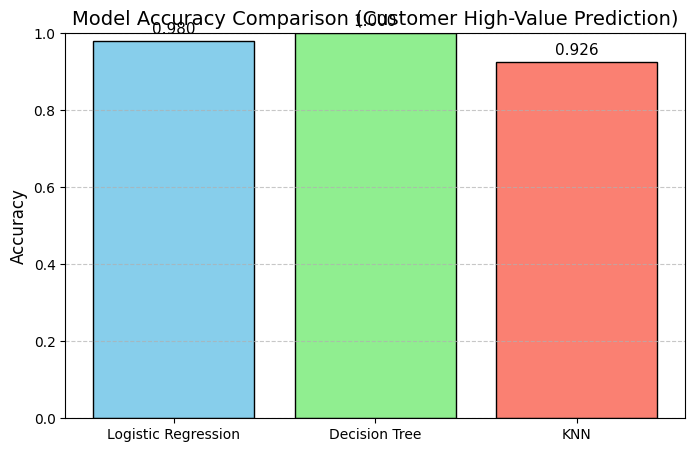

In [22]:
#Compare model performances using graph
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [acc_lr, acc_dt, acc_knn]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison (Customer High-Value Prediction)', fontsize=14)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

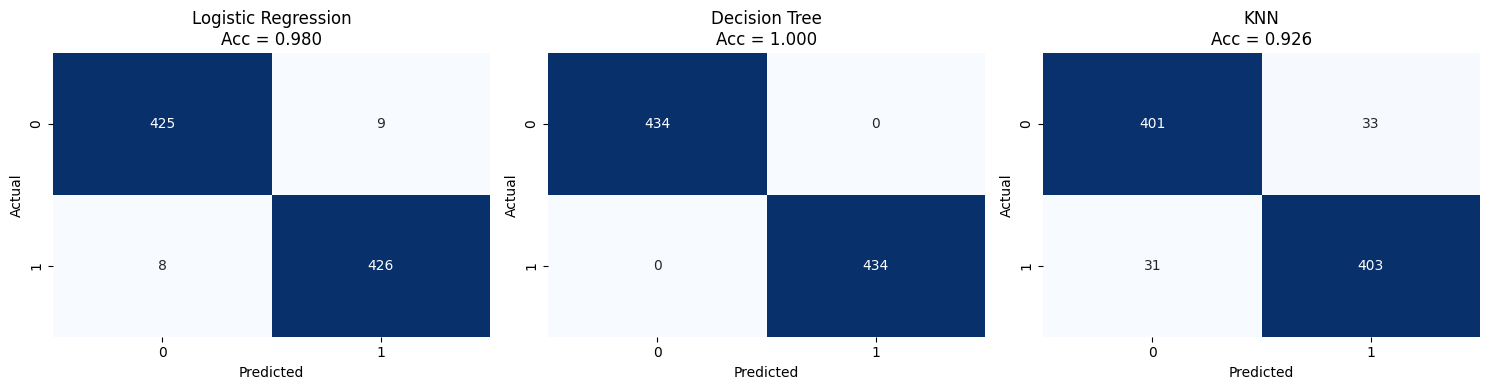

In [25]:
#Confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model_name, y_pred, acc in zip(axes, models, [y_pred_lr, y_pred_dt, y_pred_knn], accuracies):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{model_name}\nAcc = {acc:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [27]:
#Select the best model
best_model_name = models[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"BEST MODEL: {best_model_name} with Accuracy = {best_accuracy:.4f}")

#Detailed classification report for the best model
if best_model_name == 'Logistic Regression':
    final_model = best_lr
    X_test_final = X_test_scaled
elif best_model_name == 'Decision Tree':
    final_model = best_dt
    X_test_final = X_test_dt
else:
    final_model = best_knn
    X_test_final = X_test_scaled

y_pred_best = final_model.predict(X_test_final)
print("\nClassification Report of Best Model:")
print(classification_report(y_test, y_pred_best, target_names=['Low Value', 'High Value']))

BEST MODEL: Decision Tree with Accuracy = 1.0000

Classification Report of Best Model:
              precision    recall  f1-score   support

   Low Value       1.00      1.00      1.00       434
  High Value       1.00      1.00      1.00       434

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868

